In [13]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt


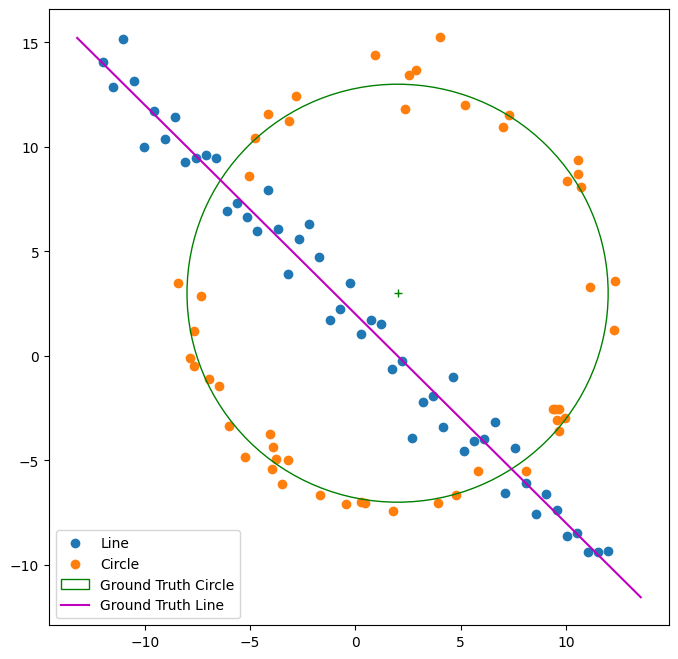

In [12]:

#np.random.seed(0)
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16

# Generate circular points
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate line points
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))


X = np.vstack((X_circ, X_line))


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

# Ground truth circle and line
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground Truth Circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground Truth Line')

plt.legend()
plt.show()


In [14]:
def fit_line_to_points(points):

    # Center the points
    centroid = np.mean(points, axis=0)
    centered = points - centroid
    
    # SVD to find the principal direction
    U, S, Vt = linalg.svd(centered)
    normal = Vt[1, :]  # Normal to the line (smallest singular vector)
    
    # Ensure unit norm
    normal = normal / np.linalg.norm(normal)
    a, b = normal
    
    # Distance from origin: d = n^T * centroid
    d = np.dot(normal, centroid)
    
    return a, b, d

In [15]:
def point_to_line_distance(points, a, b, d):
    """Calculate perpendicular distance from points to line ax + by = d"""
    # Distance = |ax + by - d| / sqrt(a^2 + b^2)
    # Since [a,b] is unit normal, denominator is 1
    distances = np.abs(points[:, 0] * a + points[:, 1] * b - d)
    return distances

In [16]:
def ransac_line(X, threshold=0.5, n_iterations=1000, min_inliers=30):
    """RANSAC for line fitting"""
    best_inliers = []
    best_params = None
    best_sample = None
    
    n_points = X.shape[0]
    
    for _ in range(n_iterations):
        # Randomly sample 2 points
        idx = np.random.choice(n_points, 2, replace=False)
        sample = X[idx]
        
        # Fit line to sample
        a, b, d = fit_line_to_points(sample)
        
        # Calculate distances for all points
        distances = point_to_line_distance(X, a, b, d)
        
        # Find inliers
        inliers_idx = np.where(distances < threshold)[0]
        
        # Update best model if this is better
        if len(inliers_idx) > len(best_inliers):
            best_inliers = inliers_idx
            best_params = (a, b, d)
            best_sample = sample
    
    # Refit line using all inliers
    if len(best_inliers) > 0:
        a, b, d = fit_line_to_points(X[best_inliers])
        best_params = (a, b, d)
    
    return best_params, best_inliers, best_sample

In [ ]:
line_params, line_inliers, line_sample = ransac_line(X, threshold=0.5, n_iterations=1000)
a, b, d = line_params

print(f"Line RANSAC Results:")
print(f"  Parameters: a={a:.4f}, b={b:.4f}, d={d:.4f}")
print(f"  Number of inliers: {len(line_inliers)}")
print(f"  Constraint check ||[a,b]|| = {np.sqrt(a**2 + b**2):.6f}")

Line RANSAC Results:
  Parameters: a=-0.7166, b=-0.6974, d=-1.4378
  Number of inliers: 51
  Constraint check ||[a,b]|| = 1.000000
